Data Understanding

In [1]:
import pandas as pd

df = pd.read_csv("Salary_dataset.csv")

df.head(10)

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [2]:
df.tail()

,Unnamed: 0,YearsExperience,Salary
25,25,9.1,105583.0
26,26,9.6,116970.0
27,27,9.7,112636.0
28,28,10.4,122392.0
29,29,10.6,121873.0


In [3]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [5]:
# Menampilkan data secara acak
df.sample(n=5)

,Unnamed: 0,YearsExperience,Salary
25,25,9.1,105583.0
10,10,4.0,63219.0
0,0,1.2,39344.0
22,22,8.0,101303.0
11,11,4.1,55795.0


In [6]:
# Memilih data baris 10 - 15
df.iloc[10:15]

,Unnamed: 0,YearsExperience,Salary
10,10,4.0,63219.0
11,11,4.1,55795.0
12,12,4.1,56958.0
13,13,4.2,57082.0
14,14,4.6,61112.0


Data Cleansing

In [7]:
df.isnull().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [8]:
df.drop_duplicates()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [9]:
# Mengubah tipe data dari float menjadi int

df["YearsExperience"] = df["YearsExperience"].astype(int)
df["Salary"] = df["Salary"].astype(int)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Unnamed: 0       30 non-null     int64
 1   YearsExperience  30 non-null     int64
 2   Salary           30 non-null     int64
dtypes: int64(3)
memory usage: 852.0 bytes


In [10]:
df.iloc[10:20]

,Unnamed: 0,YearsExperience,Salary
10,10,4,63219
11,11,4,55795
12,12,4,56958
13,13,4,57082
14,14,4,61112
15,15,5,67939
16,16,5,66030
17,17,5,83089
18,18,6,81364
19,19,6,93941


Visualisasi Data

<Axes: xlabel='YearsExperience'>

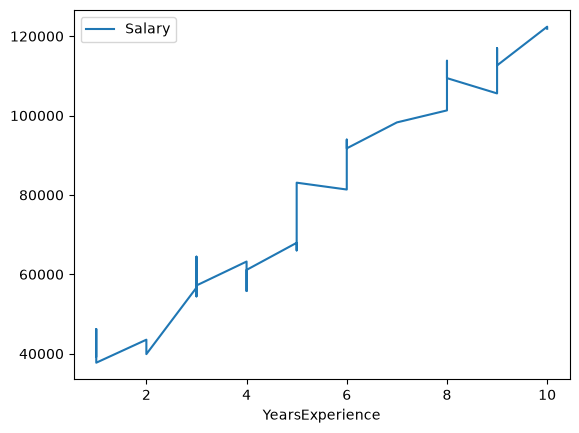

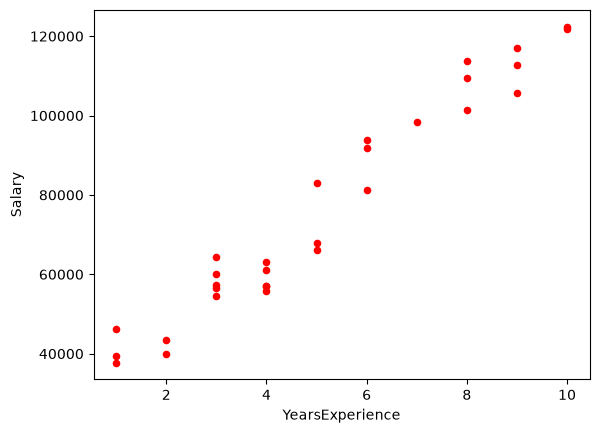

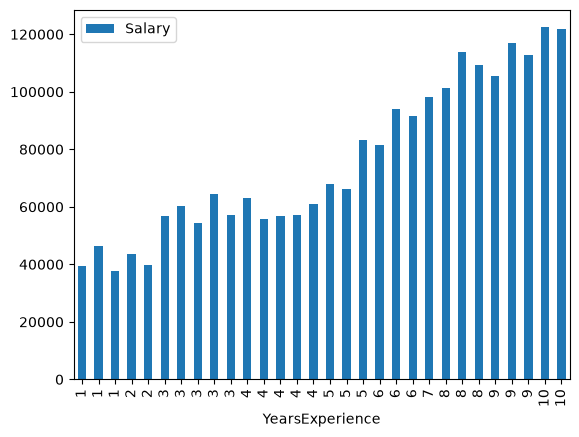

In [11]:
df.plot(x="YearsExperience", y="Salary")
df.plot.scatter(x="YearsExperience", y="Salary", color="red")
df.plot.bar(x="YearsExperience", y="Salary")

Visualisasi data dengan matplotlib

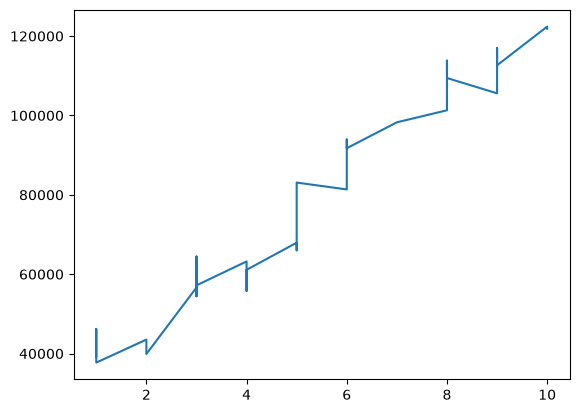

In [12]:
import matplotlib.pyplot as plt

a = df["YearsExperience"]
b = df["Salary"]

plt.plot(a, b)
plt.show()

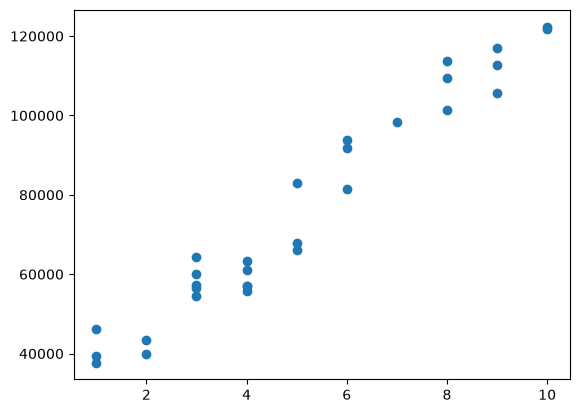

In [13]:
plt.scatter(a, b)
plt.show()

Melihat korelasi data

In [14]:
korelasi = df[["YearsExperience", "Salary"]].corr()
print(korelasi)

# semakin mendekati angka 1 semakin baik

                 YearsExperience    Salary
YearsExperience         1.000000  0.974983
Salary                  0.974983  1.000000


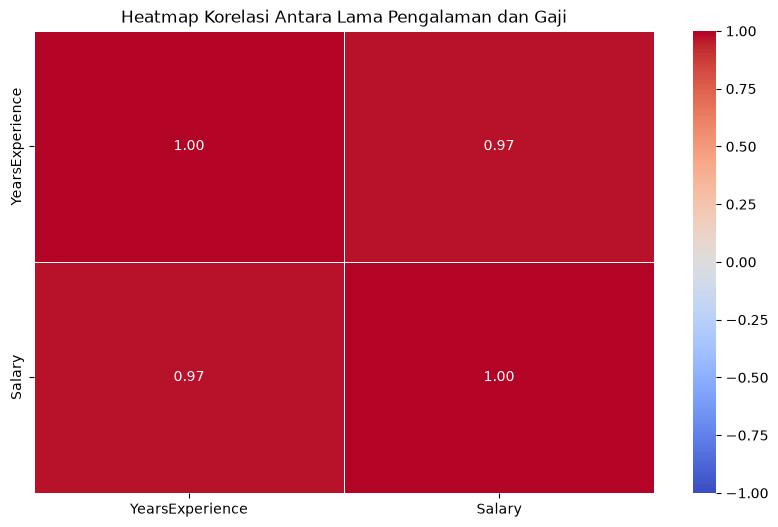

In [15]:
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.heatmap(
    korelasi,
    annot=True,        # Menampilkan nilai korelasi di dalam kotak
    cmap='coolwarm',   # Palet warna (merah=positif, biru=negatif)
    vmin=-1, vmax=1,   # Rentang nilai korelasi
    fmt=".2f",         # Format 2 angka di belakang koma
    linewidths=0.5     # Memberi garis pembatas antar kotak
)

plt.title("Heatmap Korelasi Antara Lama Pengalaman dan Gaji")
plt.show()

Data Preparation

In [16]:
X = df[["YearsExperience"]] # Kurung siku ganda untuk membuat dataframe berformat 2D
y = df["Salary"] # Kurung siku tunggal untuk membuat series
# scikit-learn memerlukan input fitur X berupa array 2 dimensi (2D).

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
# Train test split untuk membagi dataset
# test_size = 0.2 berarti membagi dataset menjadi 80% data latih dan 20% data uji
# random_state = 42 untuk memastikan hasil pembagian dataset terkunci sehingga tidak berubah-ubah setiap dijalankan

print(f"Data latih: {len(X_train)} baris")
print(f"Data uji  : {len(X_test)} baris")

Data latih: 24 baris
Data uji  : 6 baris


Membangun Model

In [18]:
from sklearn.linear_model import LinearRegression

# inisialisasi dan fitting model

model = LinearRegression()
model.fit(X_train, y_train)

# Melihat parameter garis regresi linear (y = mx + c)
print("Kemiringan (m): ", model.coef_[0])
print("Titik potong (intercept c): ", model.intercept_)

Kemiringan (m):  9617.399999999998
Titik potong (intercept c):  26121.625000000015


Evaluasi Performa Model

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# prediksi data uji
y_pred = model.predict(X_test)

# Metrik evaluasi
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Skor R2: ", r2)
print("Mean Absolute Error: ", mae)
print("RMSE: ", rmse)

Skor R2:  0.8928424540336458
Mean Absolute Error:  6272.124999999995
RMSE:  7398.353857714451


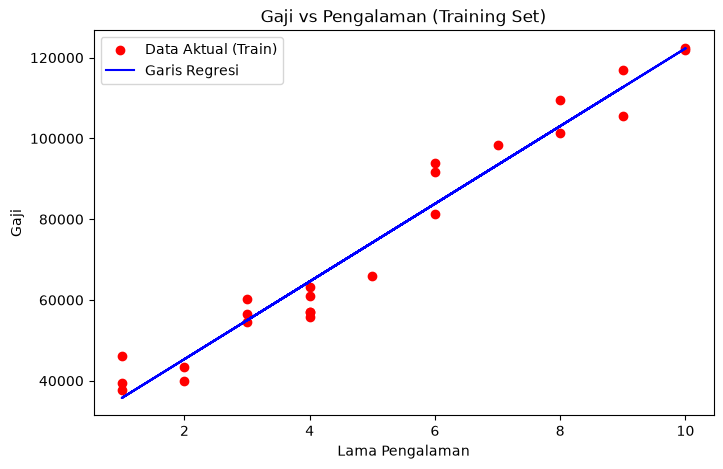

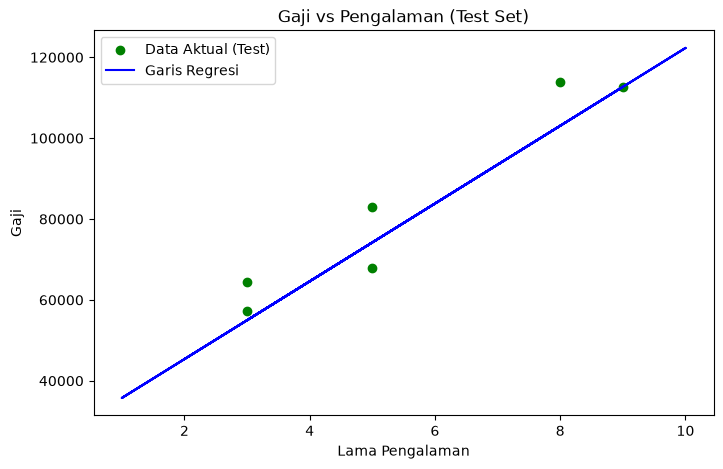

In [20]:
# Visualisasi garis regresi
# Plot data latih dan garis regresi
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color="red", label="Data Aktual (Train)")
plt.plot(X_train, model.predict(X_train), color="blue", label="Garis Regresi")
plt.title("Gaji vs Pengalaman (Training Set)")
plt.xlabel("Lama Pengalaman")
plt.ylabel("Gaji")
plt.legend()
plt.show()

# plot data uji vs garis regresi
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color="green", label="Data Aktual (Test)")
plt.plot(X_train, model.predict(X_train), color="blue", label="Garis Regresi")
plt.title("Gaji vs Pengalaman (Test Set)")
plt.xlabel("Lama Pengalaman")
plt.ylabel("Gaji")
plt.legend()
plt.show()

**Percobaan Prediksi Data Baru**

In [30]:
df.iloc[10:29]

,Unnamed: 0,YearsExperience,Salary
10,10,4,63219
11,11,4,55795
12,12,4,56958
13,13,4,57082
14,14,4,61112
15,15,5,67939
16,16,5,66030
17,17,5,83089
18,18,6,81364
19,19,6,93941


In [27]:
# Menghitung perkiraan gaji seseorang dengan pengalaman 5 tahun dan 10 tahun
data_pengalaman = np.array([[5],[10]])
prediksi_gaji = model.predict(data_pengalaman)

for pengalaman, gaji in zip(data_pengalaman, prediksi_gaji):
    print(f"Pengalaman {pengalaman[0]} tahun diprediksi memiliki gaji USD{gaji:,.0f}")

Pengalaman 5 tahun diprediksi memiliki gaji USD74,209
Pengalaman 10 tahun diprediksi memiliki gaji USD122,296


c:\Users\ACER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
